# ChiP-seq 2026

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

In [2]:
try:
    import course_utils
except:
    !pip install "course-utils @ git+https://github.com/au-mbg/molecular-biology-II.git#subdirectory=course-utils"

## Welcome to your first Bioinformatics Lab!

Right now you are in the lab working with the transcription factor TBP. You have one week to scratch the surface of cloning TBP.

The work of a real-life researcher does not end after investigating their target transcription factor for one week in the lab. Instead, many researchers rely on using bioinformatic tools to learn much more about their target.

This exercise shows what a real-life researcher might do to understand the mechanism of the transcription factor TBP even more. You will work with a real dataset from a ChIP-seq experiment investigating which sites on the humane genome TBP binds.

## How to complete this notebook

Throughout the exercise, you will answer 7 questions. The right answer will give you letters, numbers or symbols. **Note these down as you go and complete the exercise by entering the correct code at the end.**

### Question 1

You have been handed out a paper with components of a full figure illustrating the ChIP-seq workflow. However the headlines and the order have been scrambled. Please cut out each step and sort them in the correct order. **Note down the purple letters in the order you created**.

In [3]:
# Note the purple letters here
q1_answer = ""

## ChiP-seq workflow

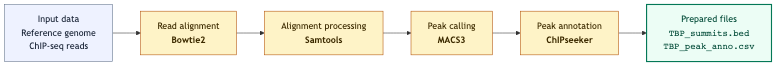

Figure 1: Diagram of ChiP-seq workflow starting from the reference genome and reads

Diagram <a href="#fig-diagram1" class="quarto-xref">Figure 1</a> shows the processing of ChIP-seq data. It uses several programs to processes the data

- [Bowtie2](https://bowtie-bio.sourceforge.net/bowtie2/index.shtml): aligns the short DNA sequences obtained from sequencing, called reads, to a reference genome. The result describes where each read most likely originated in the genome.
- [Samtools](https://github.com/samtools/samtools): processes the resulting sequence alignments. In this workflow, it is used to filter out uncertain alignments, sort the remaining reads by genomic position, and create an indexed BAM file that can be accessed efficiently.
- [MACS3](https://macs3-project.github.io/MACS/): identifies genomic regions in which unusually many aligned reads accumulate. These enriched regions are called peaks and represent candidate locations where TBP was bound to the DNA. MACS3 also identifies the summit of each peak, corresponding to the position with the strongest signal.
- [ChIPseeker](https://bioconductor.org/packages/release/bioc/html/ChIPseeker.html): compares the called peaks with known gene annotations. It classifies peaks according to the genomic features they are associated with, such as promoters, exons, introns, and intergenic regions.

The computationally demanding preprocessing has already been carried out. In this exercise, you will use Python to load the resulting files, visualise the locations of the peaks, summarise their genomic annotations, and interpret the results.

Diagram <a href="#fig-diagram2" class="quarto-xref">Figure 2</a> shows the part of the workflow that you will perform yourself.

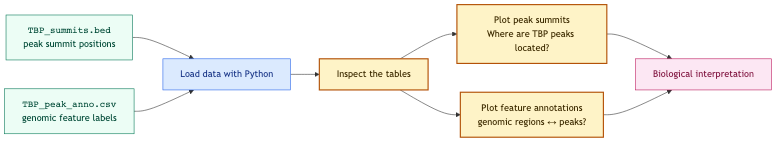

Figure 2: Diagram of analysis of processed ChiP-seq data

## Peak analysis

The code above takes all the sequenced reads as input and aligns them to the genome, matching the sequence of each read to the corresponding sequence in the genomic DNA. The number of reads binding to specific regions of the genome is then quantified and visualized as peaks in a graph. Each cluster of peaks represents a potential binding site for TBP.

The cell below loads the `TBP_summits.bed` as a dataframe.

In [5]:
summits = pd.read_csv('https://raw.githubusercontent.com/au-mbg/molecular-biology-II/refs/heads/main/data/TBP_summits.bed',
                      sep='\t', 
                      header=None, 
                      names=["chrom", "start", "end", "name", "score"])

display(summits)

The following cell creates a plot with the chromosome size on the x-axis and the peak score on the y-axis.

In [7]:
# Create figure and axis to make the plot.
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data - this creates a vertical (vline) at each "start"-position
# the line starts at 0 and goes to "score".
ax.vlines(
    x=summits["start"],
    ymin=0,
    ymax=summits["score"],
    linewidth=0.8,
    color='black'
)

# Customization: Title & axis labels
ax.set_title("ChIP Peaks over region - TBP", loc="left")
ax.set_xlabel("Chromosome Size (bp)")
ax.set_ylabel("")

# Customization: Axis limits & ticks
ax.set_xlim(0, 10_000_000)
ax.set_ylim(0, summits["score"].max() * 1.05)
ax.set_xticks([0, 2_500_000, 5_000_000, 7_500_000, 10_000_000])
ax.xaxis.set_major_formatter(FormatStrFormatter("%.1e"))

# Customization: Spines & layout
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

Use the graph to answer the following questions:

### Question 2:

What does a high peak at a binding site typically indicate compared to a low peak? Note the symbol that corresponds to the correct option below.

%) A high peak indicates that fewer reads were aligned to the binding site, suggesting weaker binding affinity of the protein at that site.

!) A high peak suggests a strong enrichment or binding affinity at that site, meaning more sequencing reads aligned to this region.

?) A high peak represents a control region where the protein does not bind, while a low peak represents an area of high binding affinity.

“) There is no difference between high and low peaks; all peaks represent equal binding affinity.

In [9]:
# Note the answer symbol here
q2_answer = ""

### Question 3:

How many regions have a peak intensity of more than 150?

In [11]:
# Note the answer symbol here
q3_answer = ""

## Analysis of TBP binding sites

Next we load the peak annotation data produced by ChIPseeker.

In [13]:
annotations = pd.read_csv("https://raw.githubusercontent.com/au-mbg/molecular-biology-II/refs/heads/main/data/TBP_peak_annotations.csv")

annotations.head()

Then we define the features we are interested in and calculate percentages.

In [15]:
feature_order = [
    "Promoter (<=1kb)",
    "Promoter (1-2kb)",
    "Promoter (2-3kb)",
    "3' UTR",
    "1st Exon",
    "Other Exon",
    "1st Intron",
    "Other Intron",
    "Downstream (<=300)",
    "Distal Intergenic",
]

counts = annotations["feature_simplified"].value_counts()
percentages = counts / counts.sum() * 100
percentages = percentages.reindex(feature_order, fill_value=0)

Finally we make a plot of the features

In [17]:
# Pick colors for each feature
colors = {
    "Promoter (<=1kb)": "#a6cee3",
    "Promoter (1-2kb)": "#1f78b4",
    "Promoter (2-3kb)": "#b2df8a",
    "3' UTR": "#33a02c",
    "1st Exon": "#fb9a99",
    "Other Exon": "#e31a1c",
    "1st Intron": "#fdbf6f",
    "Other Intron": "#ff7f00",
    "Downstream (<=300)": "#cab2d6",
    "Distal Intergenic": "#6a3d9a",
}
# Create figure and axis
fig, ax = plt.subplots(figsize=(9, 7))

# Plot the percentage of each feature as a horizontal bar. 
# The width of the bar is the percentage of that feature and 
# it starts at the cummulative percentage of all previous features, 
# stored in the variable left.
left = 0
for feature, percentage in percentages.items():
    ax.barh(
        y=["TBP"],
        width=percentage,
        left=left,
        color=colors[feature],
        label=feature,
        height=0.5,
    )
    left += percentage

# Customization: Title, limits and labels
ax.set_title("Feature Distribution", loc="left", fontsize=20)
ax.set_xlabel("Percentage(%)", fontsize=14)
ax.set_ylabel("")
ax.set_xlim(0, 105)
ax.set_xticks([0, 25, 50, 75, 100])

# Customization: Legend with feature names <-> colors.
ax.legend(
    title="Feature",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    frameon=False,
)

# Customization: Layout
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Question 4:

Which region is found **closest to the start** of a gene and helps initiate transcription?

1.  Promoter (\<=1kb)

2.  3’ UTR

3.  Other Exon

In [19]:
# Note the answer symbol here
q4_answer = "" 

### Question 5:

Which region is typically found **far from any known genes** and may or may not be involved in gene expression?

1.  1st Exon

2.  Promoter (2-3kb)

3.  Distal Intergenic

In [21]:
# Note the answer symbol here
q5_answer = ""

### Question 6:

Which region is located **after the coding sequence** of a gene and can impact mRNA stability?

1.  Promoter (1-2kb)

2.  3’ UTR

3.  1st Intron

In [23]:
# Note the answer symbol here
q6_answer = ""

### Question 7:

What kind of genomic element does TBP mostly bind to?

1.  Promoter (\<=1kb)

2.  Downstream (\<=300)

3.  Other Exon

In [25]:
# Note the answer symbol here
q7_answer = ""

## Check your answers

You have now answered all 7 questions. Run the next code cell and check to see if your answers are correct.

In [27]:
from course_utils import check_answer

answers = [q1_answer, q2_answer, q3_answer, q4_answer, q5_answer, q6_answer, q7_answer]
check_answer(answers)